## Conhcendo os dados

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
dados = pd.read_csv('/content/drive/MyDrive/Dados_Csv/dados_diabetes.csv')

In [3]:
dados.head()

,glicemia,pressao_sanguinea,dobra_cutanea_triceps,insulina,imc,idade,diabetes
0,89,66,23,94,28.1,21,NaN
1,137,40,35,168,43.1,33,NaN
2,78,50,32,88,31.0,26,sim
3,197,70,45,543,30.5,53,NaN
4,189,60,23,846,30.1,59,sim


In [4]:
dados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 394 entries, 0 to 393
Data columns (total 7 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   glicemia               394 non-null    int64  
 1   pressao_sanguinea      394 non-null    int64  
 2   dobra_cutanea_triceps  394 non-null    int64  
 3   insulina               394 non-null    int64  
 4   imc                    394 non-null    float64
 5   idade                  394 non-null    int64  
 6   diabetes               265 non-null    object 
dtypes: float64(1), int64(5), object(1)
memory usage: 21.7+ KB


In [5]:
dados.isna().sum()

,0
glicemia,0
pressao_sanguinea,0
dobra_cutanea_triceps,0
insulina,0
imc,0
idade,0
diabetes,129


In [6]:
dados.describe()

,glicemia,pressao_sanguinea,dobra_cutanea_triceps,insulina,imc,idade
count,394.000000,394.000000,394.000000,394.000000,394.000000,394.000000
mean,122.304569,70.654822,29.106599,155.548223,32.988579,30.814721
std,31.396725,12.469919,10.504273,118.775855,7.210160,10.198971
min,0.000000,24.000000,7.000000,14.000000,0.000000,21.000000
25%,99.000000,62.000000,21.000000,76.250000,28.325000,23.000000
50%,119.000000,70.000000,29.000000,125.000000,33.200000,27.000000
75%,143.000000,78.000000,36.750000,190.000000,37.075000,36.000000
max,198.000000,110.000000,63.000000,846.000000,67.100000,81.000000


In [7]:
# glicemia igual a 0
dados[dados['glicemia'] == 0]

,glicemia,pressao_sanguinea,dobra_cutanea_triceps,insulina,imc,idade,diabetes
88,0,74,20,23,27.7,21,NaN


In [8]:
# imc igual a 0
dados[dados['imc'] == 0]

,glicemia,pressao_sanguinea,dobra_cutanea_triceps,insulina,imc,idade,diabetes
186,118,64,23,89,0.0,21,NaN


Como a quantidade de dados "corrompidos" é muito pequena (2 de 394), a remoção não afetará a performance do  modelo de Machine Learning e garantirá que ele não aprenda padrões errados.

In [9]:
df = dados[(dados['glicemia'] > 0) & (dados['imc'] > 0)]

In [10]:
df['diabetes'].value_counts(dropna=False)

,count
diabetes,
nao,173
NaN,127
sim,92


In [11]:
# Proporção dos dados faltantes
df['diabetes'].isna().sum()/df.shape[0]*100

np.float64(32.39795918367347)

## Análise de Exploratória de Dados

### Distribuição do dados

In [12]:
df['glicemia'].skew()

np.float64(0.5178499371777541)

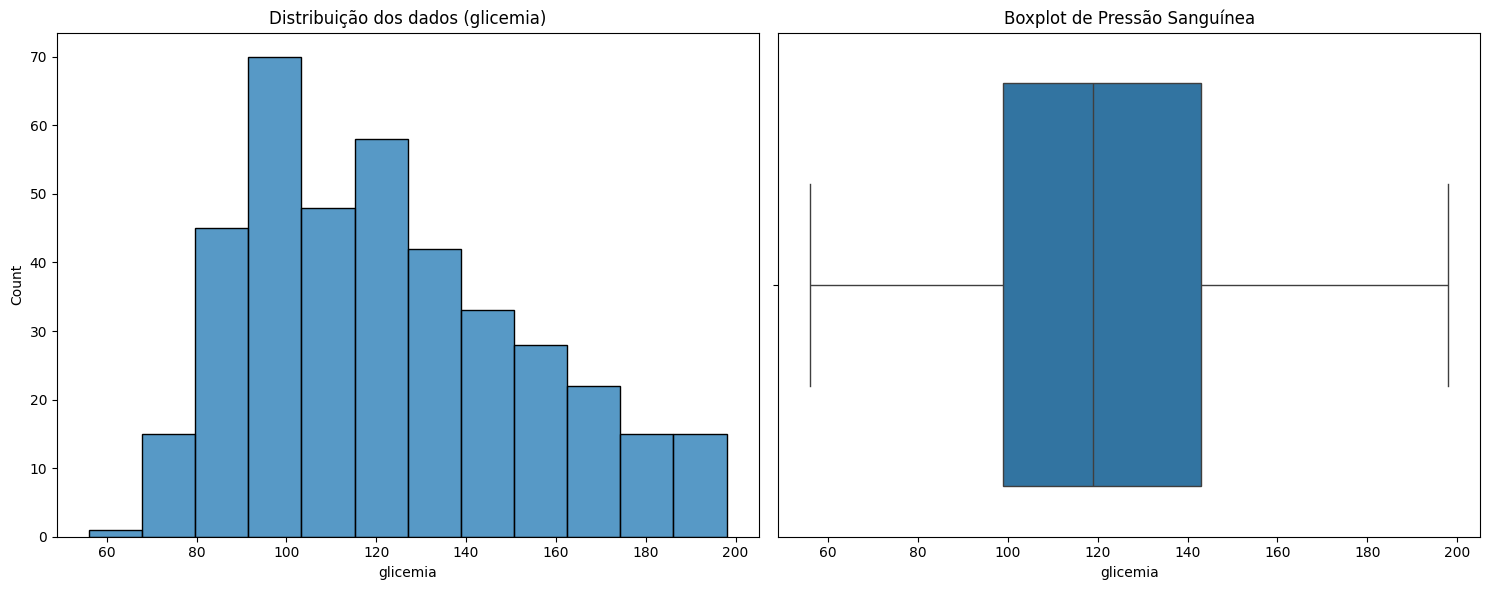

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.histplot(x='glicemia', data=df, ax=axes[0])
axes[0].set_title('Distribuição dos dados (glicemia)')

sns.boxplot(x='glicemia', data=df, ax=axes[1])
axes[1].set_title('Boxplot de Pressão Sanguínea')

plt.tight_layout()
plt.show()

In [14]:
df['pressao_sanguinea'].skew()

np.float64(-0.08751639156004226)

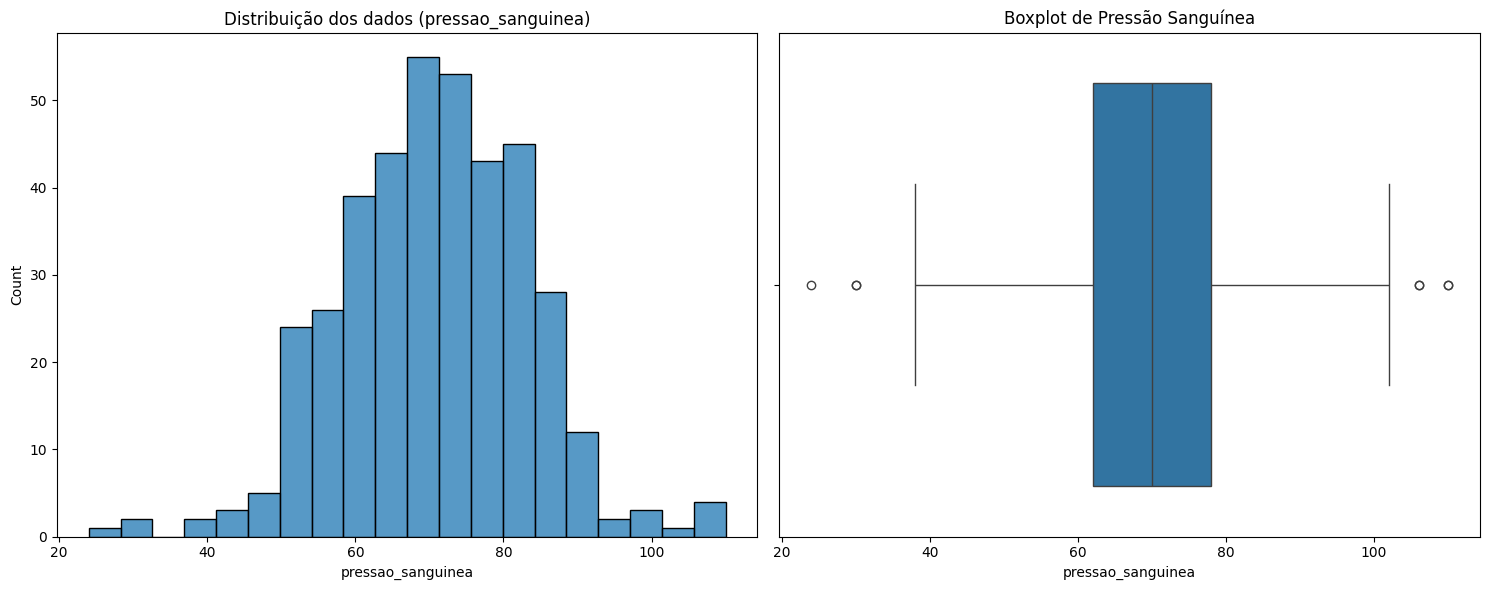

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.histplot(x='pressao_sanguinea', data=df, ax=axes[0])
axes[0].set_title('Distribuição dos dados (pressao_sanguinea)')

sns.boxplot(x='pressao_sanguinea', data=df, ax=axes[1])
axes[1].set_title('Boxplot de Pressão Sanguínea')

plt.tight_layout()
plt.show()

In [16]:
df['dobra_cutanea_triceps'].skew()

np.float64(0.20931080688997156)

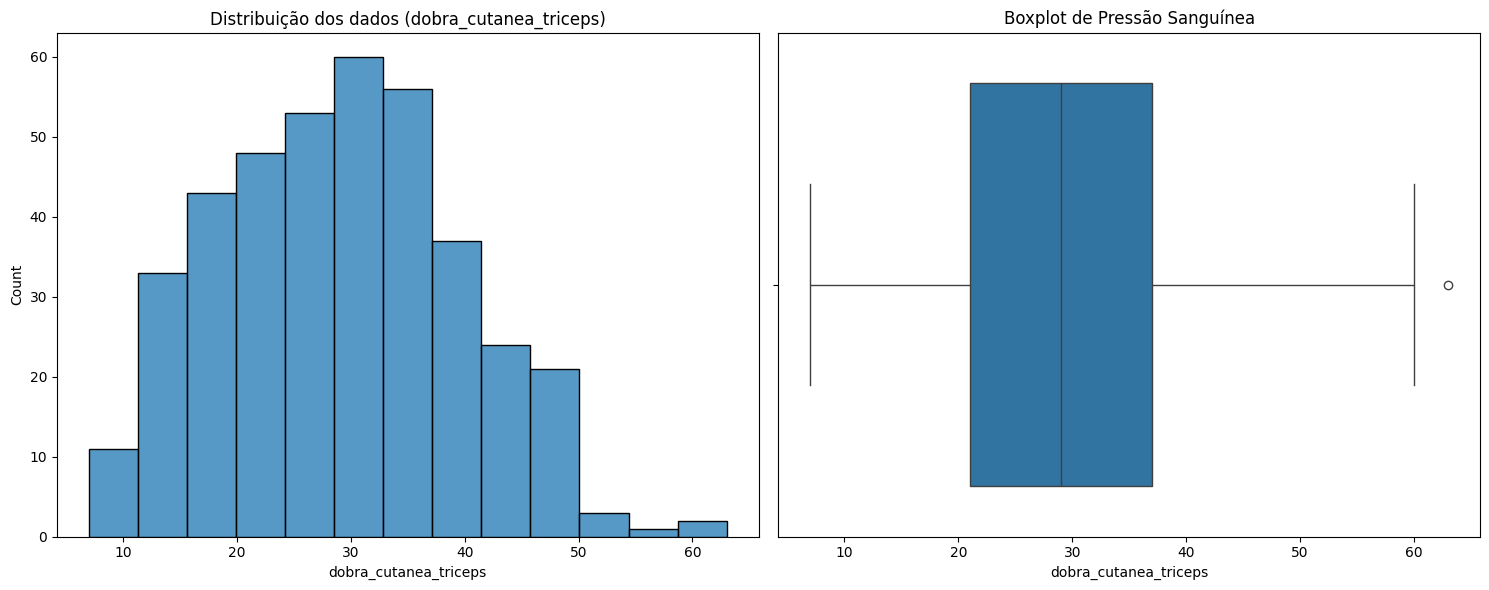

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.histplot(x='dobra_cutanea_triceps', data=df, ax=axes[0])
axes[0].set_title('Distribuição dos dados (dobra_cutanea_triceps)')

sns.boxplot(x='dobra_cutanea_triceps', data=df, ax=axes[1])
axes[1].set_title('Boxplot de Pressão Sanguínea')

plt.tight_layout()
plt.show()

In [18]:
df['insulina'].skew()

np.float64(2.1651161863573374)

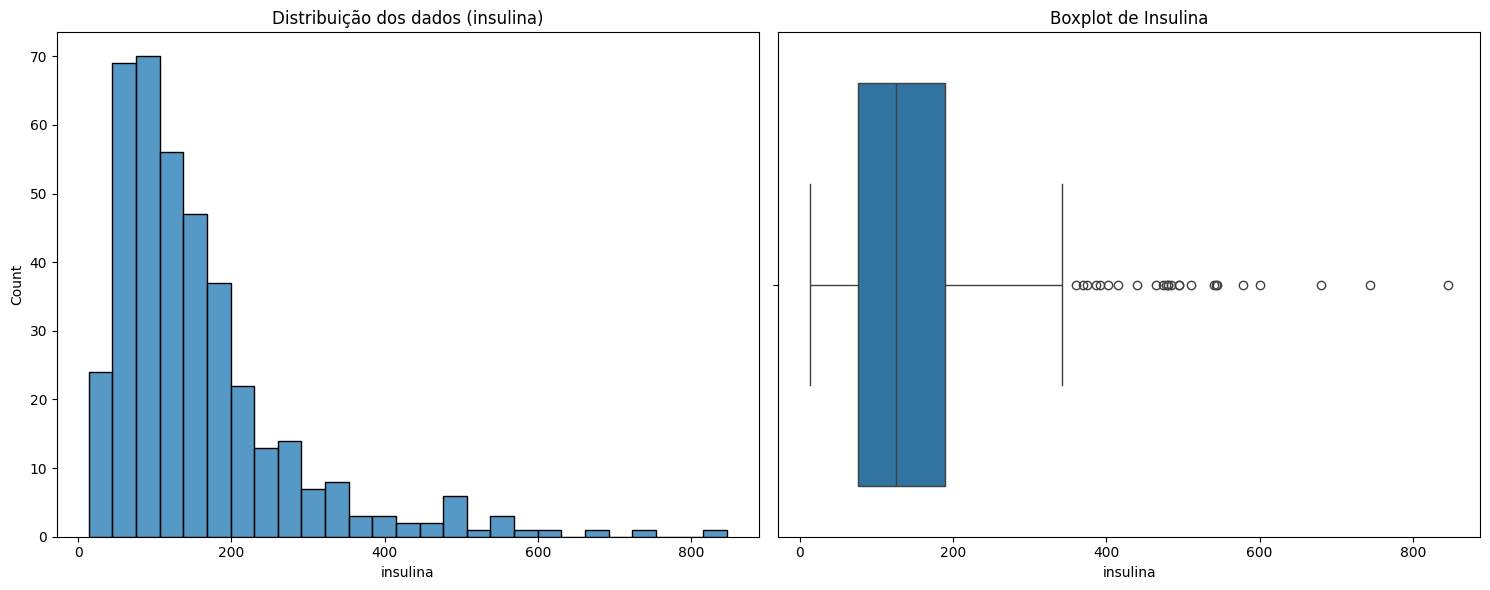

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.histplot(x='insulina', data=df, ax=axes[0])
axes[0].set_title('Distribuição dos dados (insulina)')

sns.boxplot(x='insulina', data=df, ax=axes[1])
axes[1].set_title('Boxplot de Insulina')

plt.tight_layout()
plt.show()

In [20]:
df['imc'].skew()

np.float64(0.663485056210774)

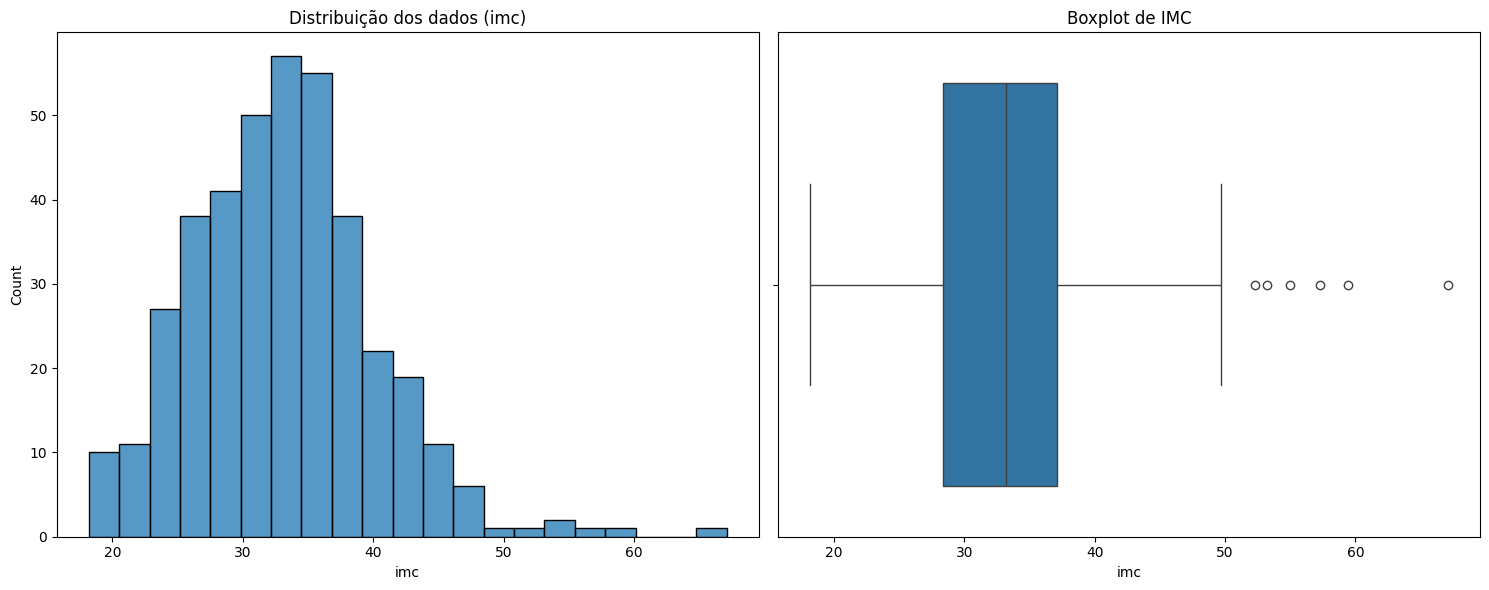

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.histplot(x='imc', data=df, ax=axes[0])
axes[0].set_title('Distribuição dos dados (imc)')

sns.boxplot(x='imc', data=df, ax=axes[1])
axes[1].set_title('Boxplot de IMC')

plt.tight_layout()
plt.show()

In [22]:
df['idade'].skew()

np.float64(1.4036065447817476)

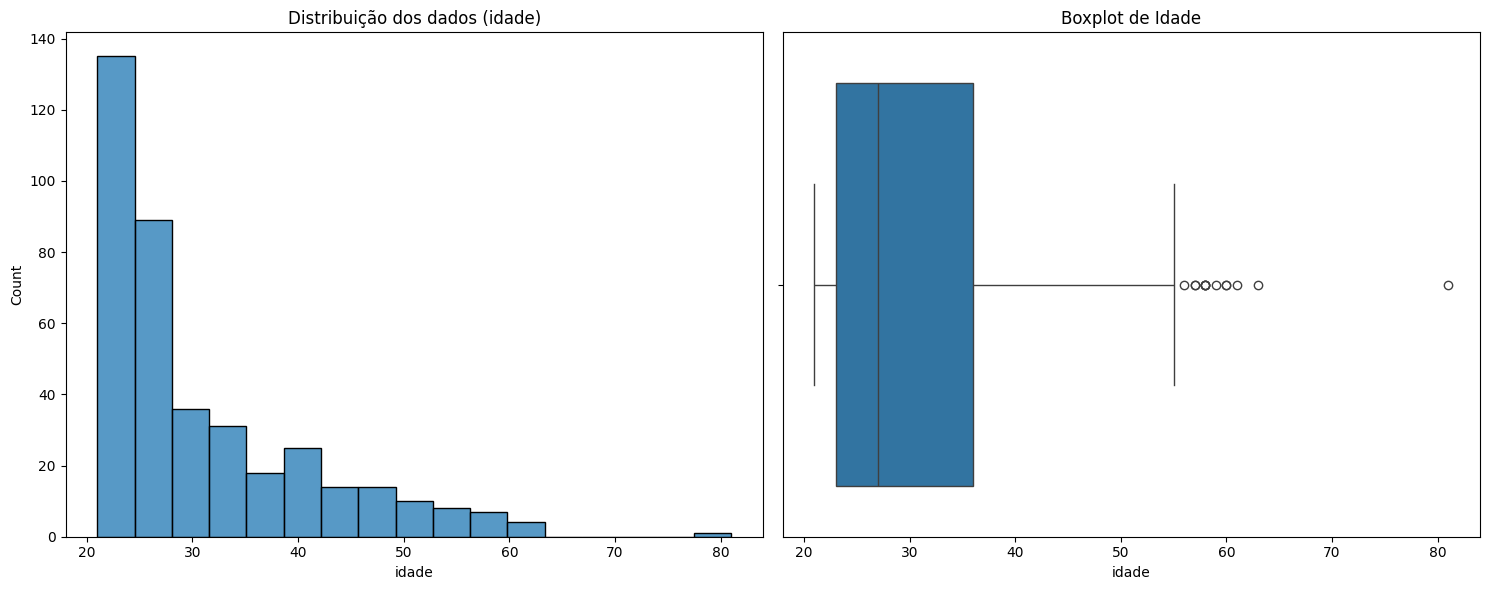

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.histplot(x='idade', data=df, ax=axes[0])
axes[0].set_title('Distribuição dos dados (idade)')

sns.boxplot(x='idade', data=df, ax=axes[1])
axes[1].set_title('Boxplot de Idade')

plt.tight_layout()
plt.show()

Assimetria:
* **glicemia**: 0.5178
* **pressao_sanguinea**: -0.0875
* **dobra_cutanea_triceps**: 0.2093
* **insulina**: 2.1651
* **imc**: 0.6635
* **idade**: 1.4036

### Relação entre as variáveis

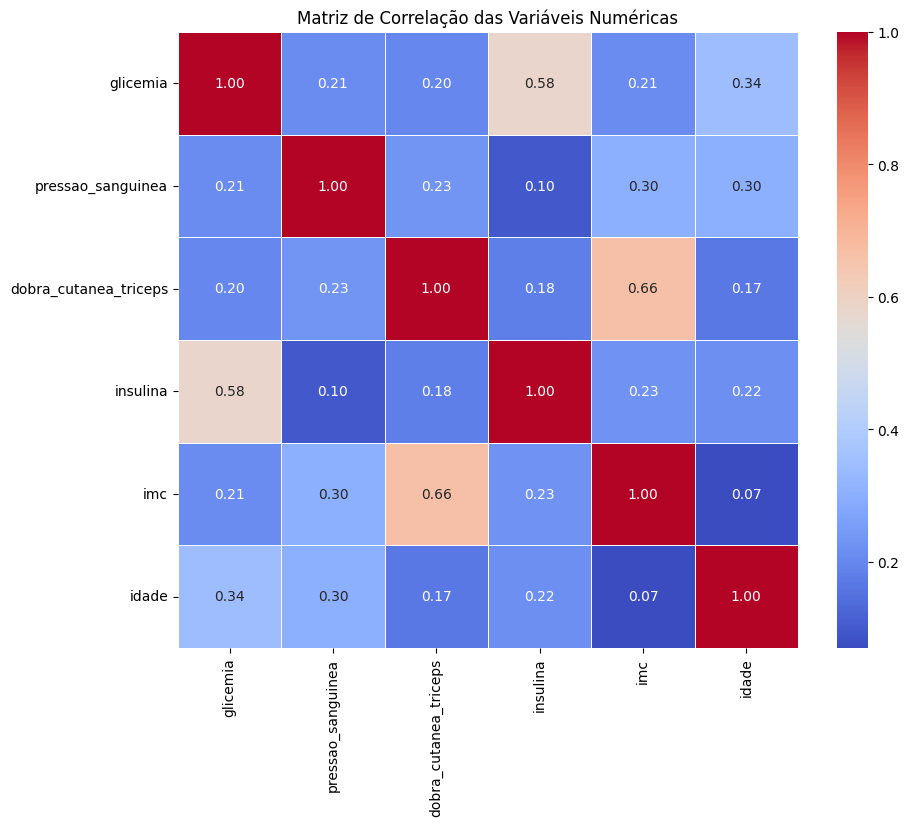

In [24]:
plt.figure(figsize=(10, 8))
correlation_matrix = df.select_dtypes(include=['number']).corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Matriz de Correlação das Variáveis Numéricas')
plt.show()

In [25]:
def relacao_variaveis_grafico(x, y, data, title=None, xlabel=None, ylabel=None, figsize=(10, 6), hue=None):
  plt.figure(figsize=figsize)

  sns.regplot(x=x, y=y, data=data, scatter=True, line_kws={'color': 'red'})

  if title:
    plt.title(title)
  else:
    plt.title(f'Relação entre {x} e {y}')

  if xlabel:
    plt.xlabel(xlabel)
  else:
    plt.xlabel(x)

  if ylabel:
    plt.ylabel(ylabel)
  else:
    plt.ylabel(y)

  plt.grid(True, linestyle='--', alpha=0.7)
  plt.tight_layout()
  plt.show()

In [26]:
dados.columns

Index(['glicemia', 'pressao_sanguinea', 'dobra_cutanea_triceps', 'insulina',
       'imc', 'idade', 'diabetes'],
      dtype='object')

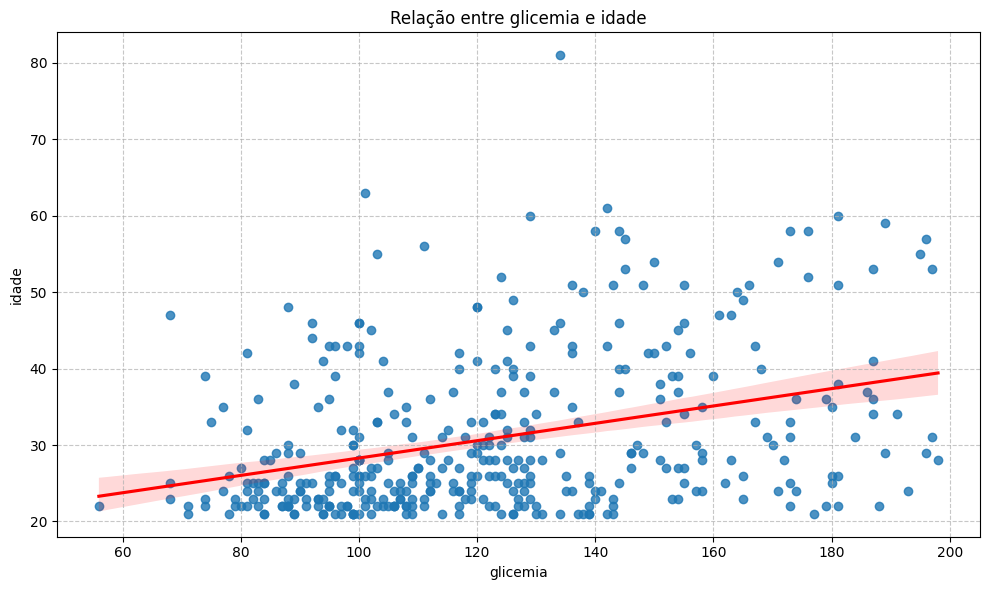

In [27]:
relacao_variaveis_grafico('glicemia','idade', df)

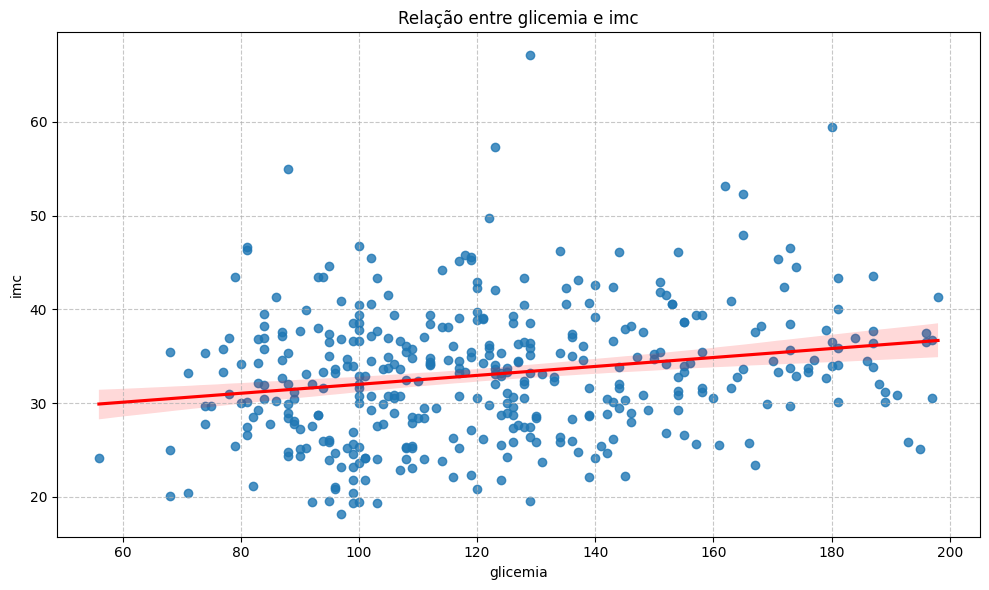

In [28]:
relacao_variaveis_grafico('glicemia','imc', df)

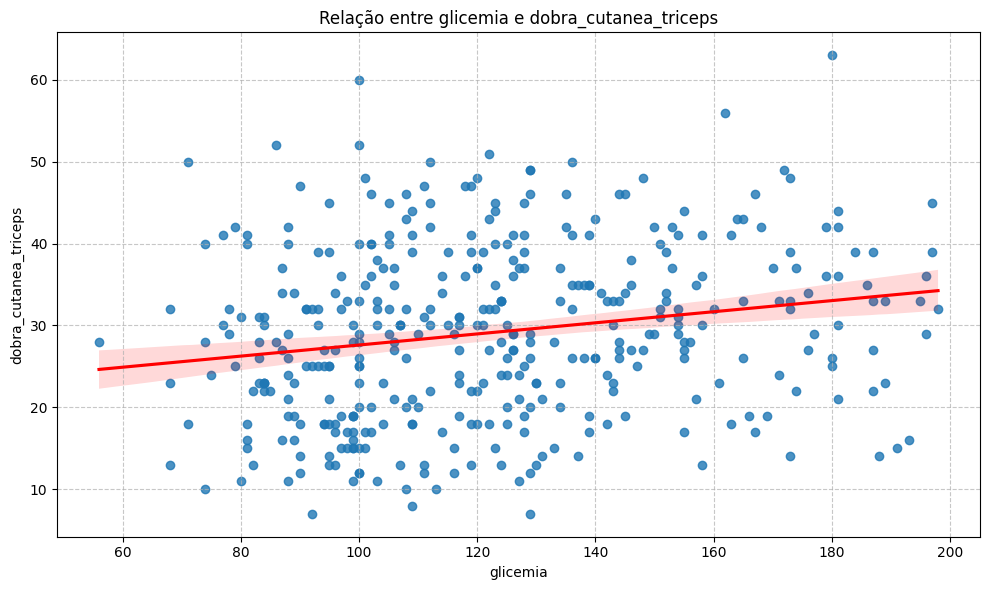

In [29]:
relacao_variaveis_grafico('glicemia','dobra_cutanea_triceps', df)

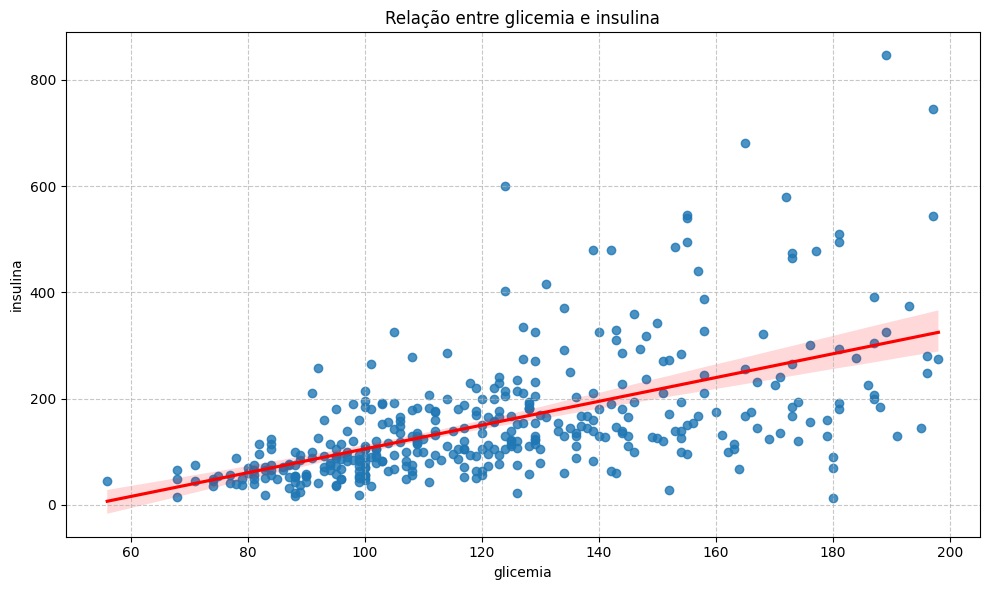

In [30]:
relacao_variaveis_grafico('glicemia','insulina', df)

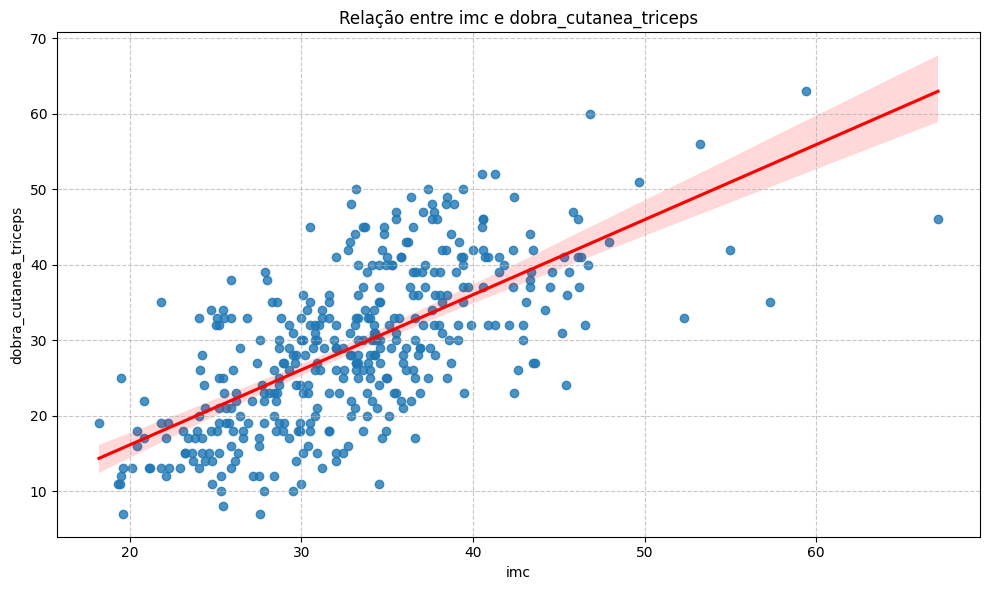

In [31]:
relacao_variaveis_grafico('imc','dobra_cutanea_triceps', df)

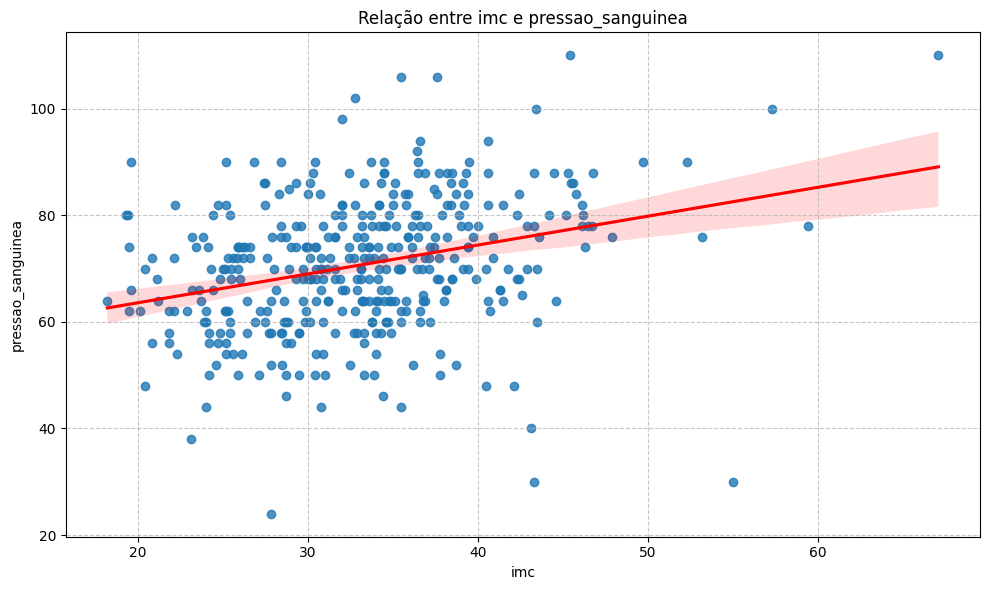

In [32]:
relacao_variaveis_grafico('imc','pressao_sanguinea', df)

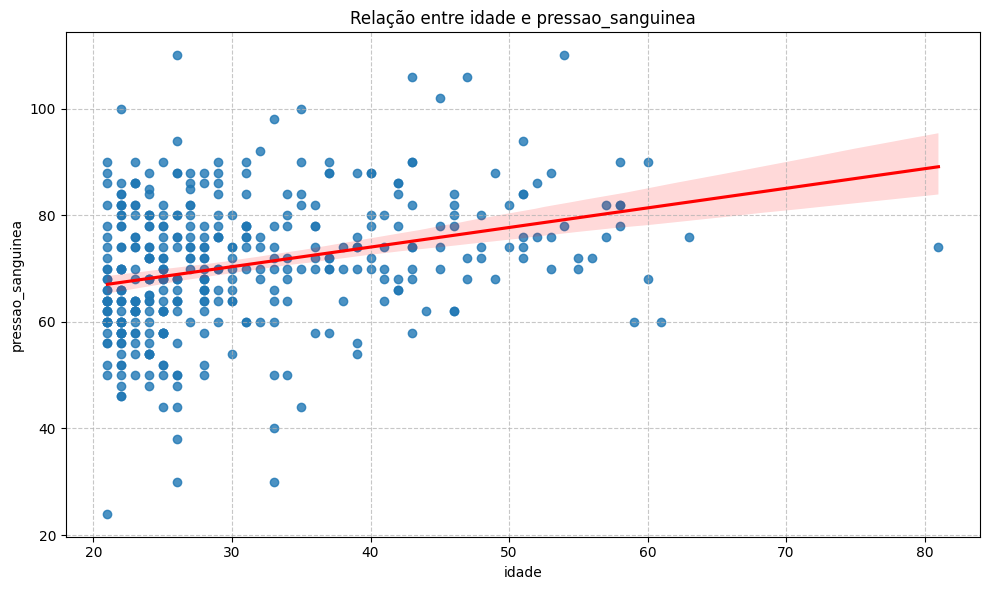

In [33]:
relacao_variaveis_grafico('idade','pressao_sanguinea', df)

## Transformação logaritima

Visto que há assimitria na distribuição em várias variaveis, acredito que seja necessário uma transformação para se aproximar de uma distribuição normal

In [34]:
#verificando se há alguma variavel que tem minimo zero para poder usa log
df.describe()

,glicemia,pressao_sanguinea,dobra_cutanea_triceps,insulina,imc,idade
count,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000
mean,122.627551,70.663265,29.145408,156.056122,33.086224,30.864796
std,30.860781,12.496092,10.516424,118.841690,7.027659,10.200777
min,56.000000,24.000000,7.000000,14.000000,18.200000,21.000000
25%,99.000000,62.000000,21.000000,76.750000,28.400000,23.000000
50%,119.000000,70.000000,29.000000,125.500000,33.200000,27.000000
75%,143.000000,78.000000,37.000000,190.000000,37.100000,36.000000
max,198.000000,110.000000,63.000000,846.000000,67.100000,81.000000


In [35]:
import numpy as np

dados_tf = df.copy()

colunas_log = ['insulina', 'idade', 'imc', 'glicemia']

for coluna in colunas_log:
  dados_tf[coluna] = np.log(dados_tf[coluna])

In [36]:
dados_tf

,glicemia,pressao_sanguinea,dobra_cutanea_triceps,insulina,imc,idade,diabetes
0,4.488636,66,23,4.543295,3.335770,3.044522,NaN
1,4.919981,40,35,5.123964,3.763523,3.496508,NaN
2,4.356709,50,32,4.477337,3.433987,3.258097,sim
3,5.283204,70,45,6.297109,3.417727,3.970292,NaN
4,5.241747,60,23,6.740519,3.404525,4.077537,sim
...,...,...,...,...,...,...,...
389,5.198497,88,44,6.234411,3.768153,3.258097,NaN
390,4.852030,88,39,4.700480,3.597312,3.610918,sim
391,4.477337,58,26,2.772589,3.346389,3.091042,nao
392,4.615121,76,48,5.192957,3.493473,4.143135,nao


In [37]:
print(dados_tf['glicemia'].skew())
print(dados_tf['insulina'].skew())
print(dados_tf['imc'].skew())
print(dados_tf['idade'].skew())

0.03580916725731411
-0.1027717045315826
-0.1006899172842389
0.8556852938338932


Assimetria (antes e depois):
* **glicemia**: 0.5178 -> 0.0358
* **insulina**: 2.1651 -> -0.1027
* **imc**: 0.6635 -> -0.1006
* **idade**: 1.4036 -> 0.8556

### Analisando a distribuição após a transformação

In [38]:
def plot_histograma(df, coluna):
  fig, axes = plt.subplots(1, 2, figsize=(15, 6))

  sns.histplot(x=coluna, data=df, kde=True, ax=axes[0])
  axes[0].set_title(f'Distribuição de {coluna} após transformação logarítmica')
  axes[0].set_xlabel(coluna)
  axes[0].set_ylabel('Frequência')

  sns.boxplot(x=coluna, data=df, ax=axes[1])
  axes[1].set_title(f'Boxplot de {coluna}')
  axes[1].set_xlabel(coluna)

  plt.tight_layout()
  plt.show()

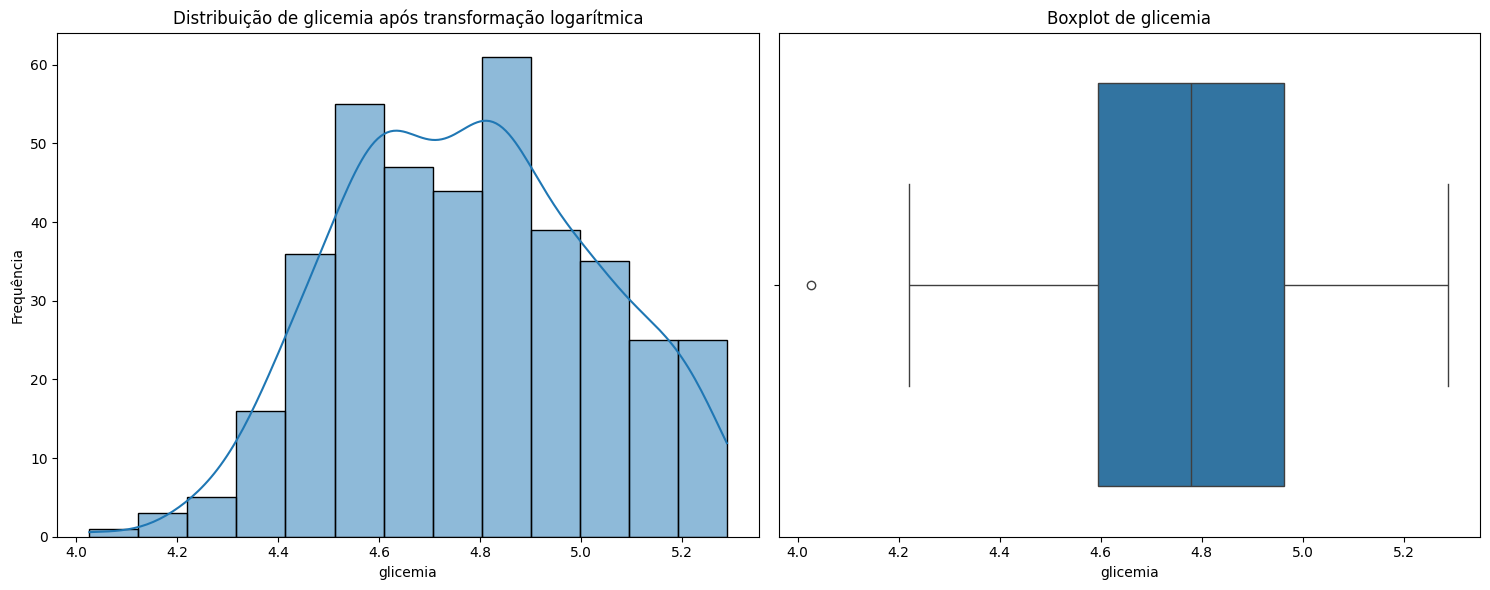

In [39]:
plot_histograma(dados_tf, 'glicemia')

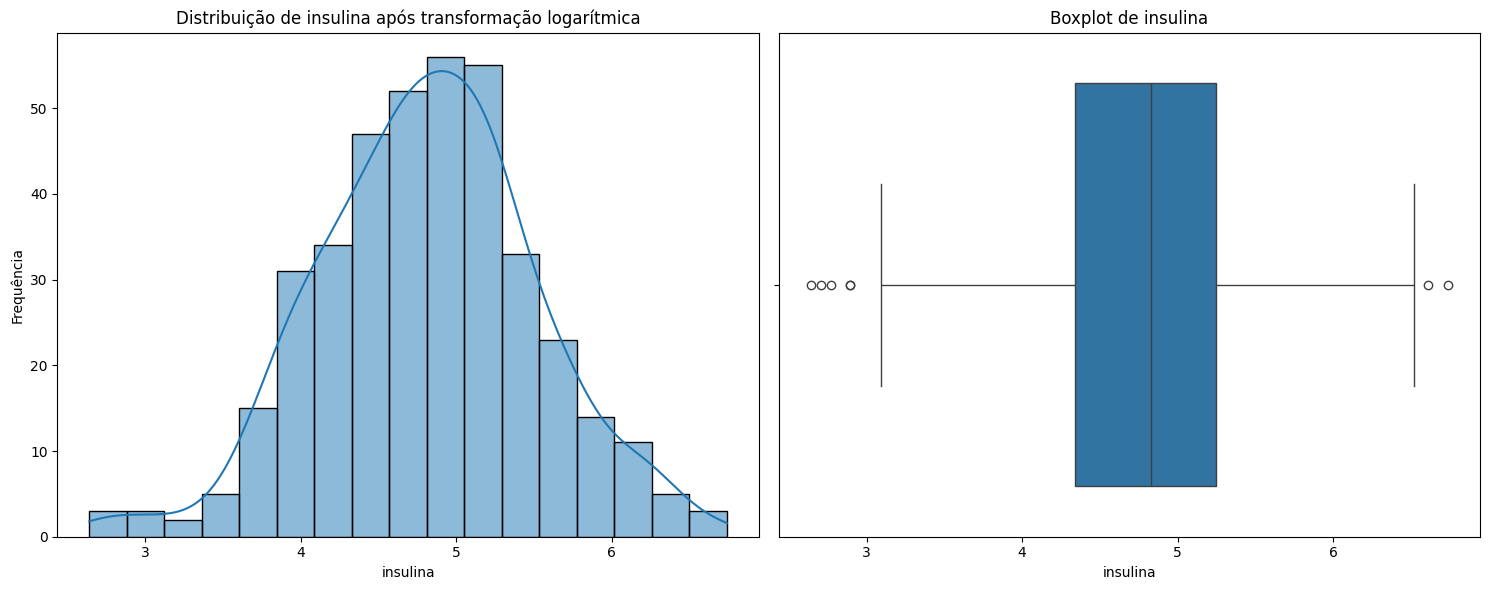

In [40]:
plot_histograma(dados_tf, 'insulina')

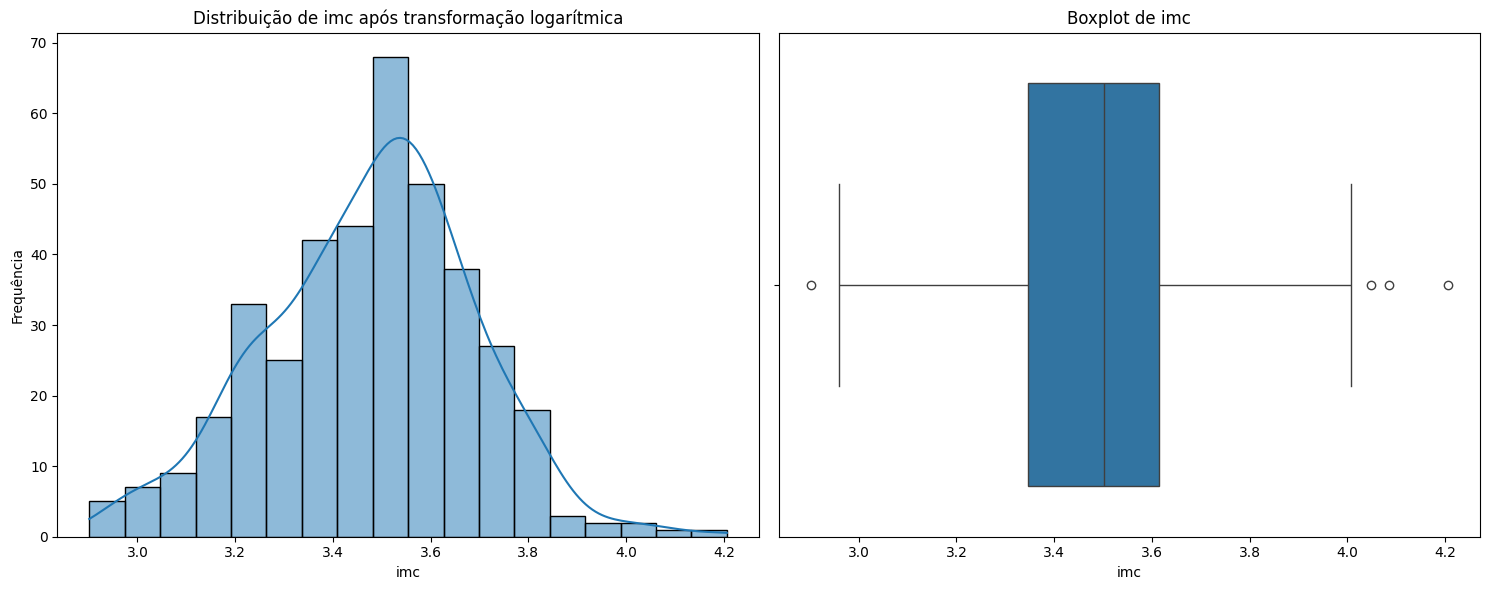

In [41]:
plot_histograma(dados_tf, 'imc')

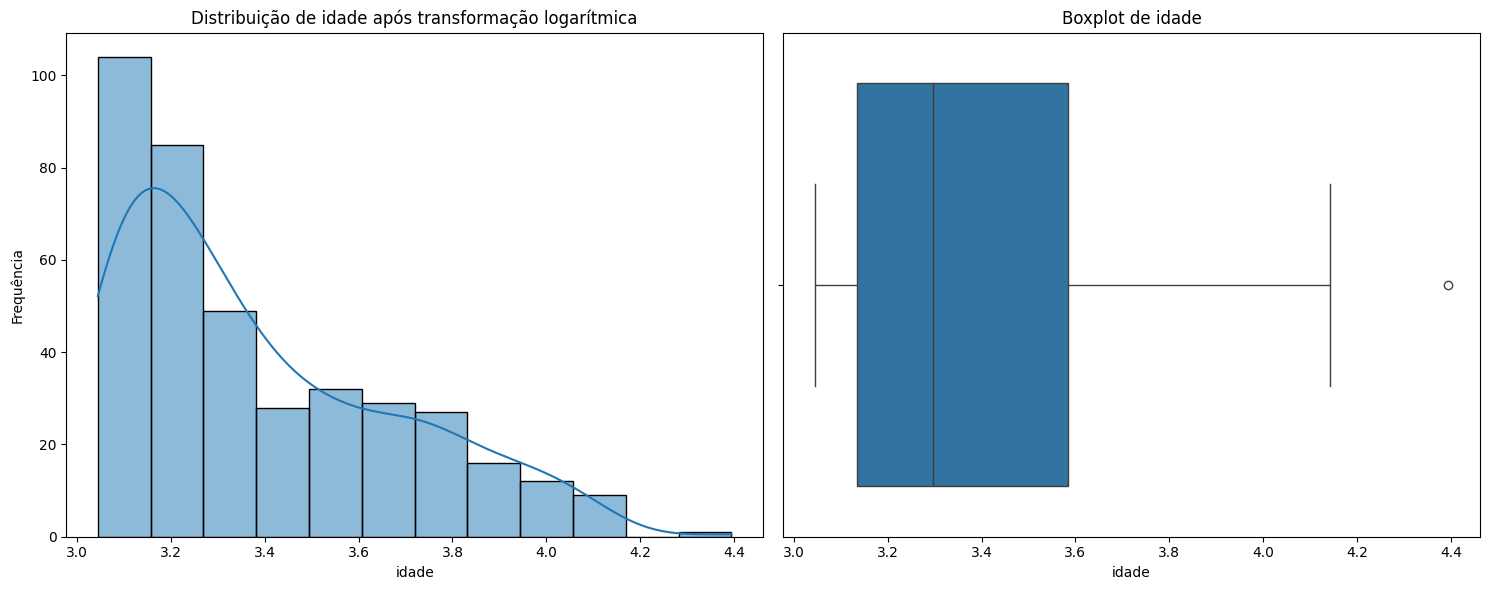

In [42]:
plot_histograma(dados_tf, 'idade')

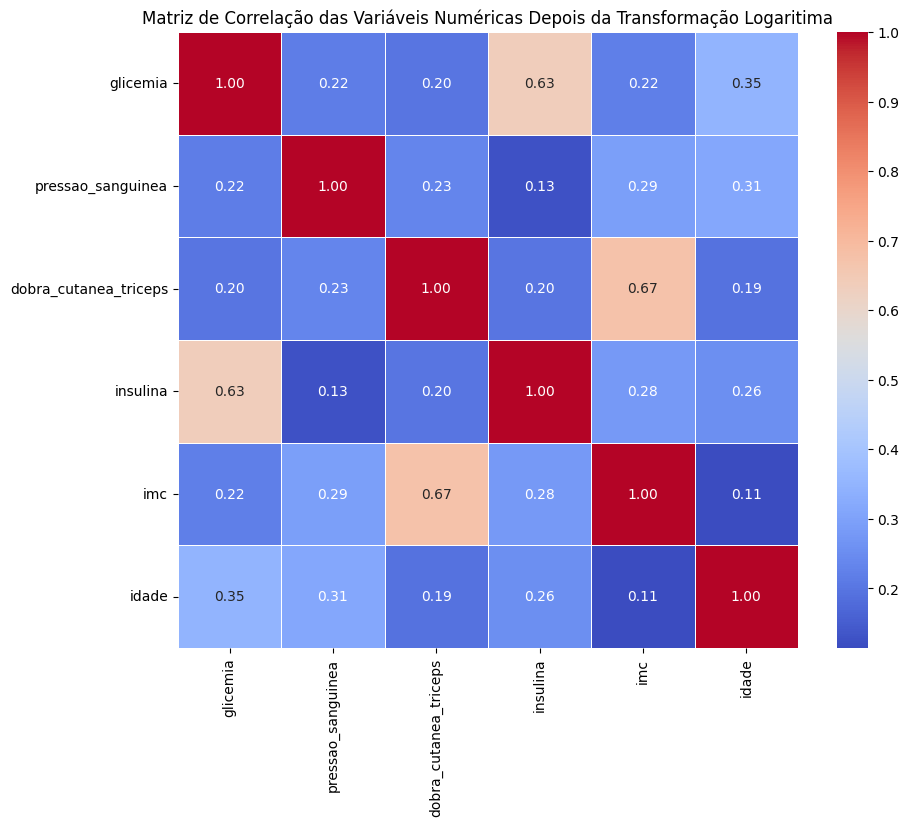

In [43]:
plt.figure(figsize=(10, 8))
correlation_matrix = dados_tf.select_dtypes(include=['number']).corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Matriz de Correlação das Variáveis Numéricas Depois da Transformação Logaritima')
plt.show()

## Escalonamento (padronização)

In [44]:
dados_tf.head()

,glicemia,pressao_sanguinea,dobra_cutanea_triceps,insulina,imc,idade,diabetes
0,4.488636,66,23,4.543295,3.335770,3.044522,NaN
1,4.919981,40,35,5.123964,3.763523,3.496508,NaN
2,4.356709,50,32,4.477337,3.433987,3.258097,sim
3,5.283204,70,45,6.297109,3.417727,3.970292,NaN
4,5.241747,60,23,6.740519,3.404525,4.077537,sim


In [45]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

colunas_para_svm = ['glicemia', 'pressao_sanguinea', 'dobra_cutanea_triceps', 'insulina', 'imc', 'idade']

dados_tf_escalonados = pd.DataFrame(scaler.fit_transform(dados_tf[colunas_para_svm]), columns=dados_tf[colunas_para_svm].columns)
dados_tf_escalonados = pd.concat([dados_tf_escalonados, dados_tf['diabetes']], axis=1)
dados_tf_escalonados

,glicemia,pressao_sanguinea,dobra_cutanea_triceps,insulina,imc,idade,diabetes
0,-1.160221,-0.373655,-0.585110,-0.388535,-0.667971,-1.162736,NaN
1,0.568966,-2.456964,0.557421,0.447601,1.356175,0.386818,NaN
2,-1.689096,-1.655691,0.271788,-0.483512,-0.203201,-0.430534,sim
3,2.025064,-0.053146,1.509530,2.136876,-0.280147,2.011106,NaN
4,1.858871,-0.854419,-0.585110,2.775366,-0.342617,2.378779,sim
...,...,...,...,...,...,...,...
389,-1.205519,-1.014673,-0.299477,-2.938270,-0.617718,-1.003250,NaN
390,-0.653168,0.427618,1.795162,0.546948,0.078286,2.603668,sim
391,0.071107,0.107109,-0.585110,-0.136250,-0.999261,0.060063,nao
392,NaN,NaN,NaN,NaN,NaN,NaN,nao


### Aprendizado Supervisionado

#### Selecionando dados rotulados

In [46]:
dados_rotulados = dados_tf_escalonados.dropna()
dados_rotulados

,glicemia,pressao_sanguinea,dobra_cutanea_triceps,insulina,imc,idade,diabetes
2,-1.689096,-1.655691,0.271788,-0.483512,-0.203201,-0.430534,sim
4,1.858871,-0.854419,-0.585110,2.775366,-0.342617,2.378779,sim
5,1.338688,0.107109,-0.965953,0.506383,-1.072063,1.879231,sim
7,-0.574561,-3.258237,0.843053,-0.567744,1.378082,0.386818,nao
8,-0.132775,-0.053146,0.081366,-0.358219,0.316691,0.281322,sim
...,...,...,...,...,...,...,...
385,1.816223,-0.053146,-0.680321,0.698662,0.556677,0.685121,nao
387,1.685489,1.389146,1.414319,2.046593,1.378082,-0.430534,sim
388,0.296563,1.389146,0.938264,-0.162195,0.569659,0.779054,nao
390,-0.653168,0.427618,1.795162,0.546948,0.078286,2.603668,sim


In [47]:
x = dados_rotulados.drop('diabetes', axis = 1)
y = dados_rotulados['diabetes']

In [48]:
dados_rotulados['diabetes'].value_counts(dropna=False)

,count
diabetes,
nao,171
sim,92


#### Preparando os dados (variavel alvo)

In [49]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y)

In [50]:
pd.Series(y).value_counts(normalize=True)

,proportion
0,0.65019
1,0.34981


### Criando Modelo Supervisionado

In [51]:
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import classification_report

In [52]:
x_treino, x_teste, y_treino, y_teste = train_test_split(x, y, stratify = y, random_state = 10)

In [53]:
svm = SVC(kernel = 'rbf', random_state = 10)
svm.fit(x_treino, y_treino)

SVC(random_state=10)

In [54]:
x_treino

,glicemia,pressao_sanguinea,dobra_cutanea_triceps,insulina,imc,idade
226,-0.693057,0.107109,-1.632429,-0.813033,-1.164670,-0.176467
134,0.539597,0.267364,-0.299477,0.132699,-1.035522,1.879231
353,0.655803,0.267364,-0.299477,0.546948,-1.394612,-0.850855
319,-0.238742,1.228891,1.223897,0.377346,0.809788,-0.176467
41,0.768735,0.107109,-0.204266,0.887337,0.219975,1.046332
...,...,...,...,...,...,...
374,0.358717,0.587873,-0.585110,-0.638867,-0.617718,0.489163
100,-0.856705,-0.533909,-0.204266,-0.499969,0.121240,-1.162736
31,-0.693057,-0.373655,-0.870742,-0.451152,0.078286,-0.176467
291,-0.898683,-1.335182,-1.442008,-0.483512,-1.017357,-1.003250


In [55]:
y_previsto = svm.predict(x_teste)
resultados_svm = classification_report(y_teste, y_previsto)
print(resultados_svm)

              precision    recall  f1-score   support

           0       0.64      0.91      0.75        43
           1       0.20      0.04      0.07        23

    accuracy                           0.61        66
   macro avg       0.42      0.48      0.41        66
weighted avg       0.49      0.61      0.51        66



### testando modelo com dados sem log + RobustScaler + Linear

In [56]:
dados_rotulados_2 = df.dropna()

In [57]:
x = dados_rotulados_2.drop('diabetes', axis = 1)
y = dados_rotulados_2['diabetes']

y = label_encoder.transform(y)

In [58]:
from sklearn.preprocessing import RobustScaler

In [59]:
scaler_r = RobustScaler()
x_normalizado = pd.DataFrame(scaler_r.fit_transform(x), columns=x.columns)
x_normalizado

,glicemia,pressao_sanguinea,dobra_cutanea_triceps,insulina,imc,idade
0,-0.956522,-1.375,0.1875,-0.363636,-0.261905,-0.090909
1,1.456522,-0.750,-0.3750,6.527273,-0.369048,2.909091
2,0.956522,0.000,-0.6250,0.427273,-0.880952,2.181818
3,-0.413043,-2.625,0.5625,-0.409091,1.202381,0.545455
4,-0.152174,-0.125,0.0625,-0.290909,0.166667,0.454545
...,...,...,...,...,...,...
260,-0.021739,0.375,0.6250,-0.490909,0.690476,0.090909
261,0.130435,1.000,0.6250,-0.163636,0.392857,0.909091
262,-0.739130,-0.875,-0.1875,-1.018182,-0.571429,-0.454545
263,-0.456522,0.250,1.1875,0.472727,-0.035714,3.272727


In [60]:
x_treino, x_teste, y_treino, y_teste = train_test_split(x_normalizado, y, stratify = y, random_state = 10)

In [61]:
svm = SVC(kernel = 'linear', random_state = 10)
svm.fit(x_treino, y_treino)

SVC(kernel='linear', random_state=10)

In [62]:
y_previsto = svm.predict(x_teste)
resultados_svm = classification_report(y_teste, y_previsto)
print(resultados_svm)

              precision    recall  f1-score   support

           0       0.86      0.95      0.90        44
           1       0.89      0.70      0.78        23

    accuracy                           0.87        67
   macro avg       0.87      0.83      0.84        67
weighted avg       0.87      0.87      0.86        67



## Entendo o motivo do problema do underfitting

O Primeiro modelo deu underfitting e possivelmente um dos motivos seja que a transformação teve um efeito de achatamento nos dados. No SVM, a distância entre os pontos é o que define a importância de cada variável.

In [63]:
def plot_comparison_log_transform(df_original, df_transformed, variable_name, x_axis_variable):
  """
  Gera gráficos comparativos para uma variável antes e depois da transformação logarítmica.

  Args:
    df_original (pd.DataFrame): DataFrame original.
    df_transformed (pd.DataFrame): DataFrame após a transformação logarítmica.
    variable_name (str): Nome da coluna a ser comparada (eixo Y).
    x_axis_variable (str): Nome da coluna para o eixo X.
  """
  plt.figure(figsize=(12, 5))

  # Antes do Log
  plt.subplot(1, 2, 1)
  sns.scatterplot(data=df_original, x=x_axis_variable, y=variable_name, hue='diabetes')
  plt.title(f'Original: {variable_name} vs {x_axis_variable}')

  # Depois do Log
  plt.subplot(1, 2, 2)
  sns.scatterplot(data=df_transformed, x=x_axis_variable, y=variable_name, hue='diabetes')
  plt.title(f'Pós-Log: {variable_name} vs {x_axis_variable}')

  plt.tight_layout()
  plt.show()

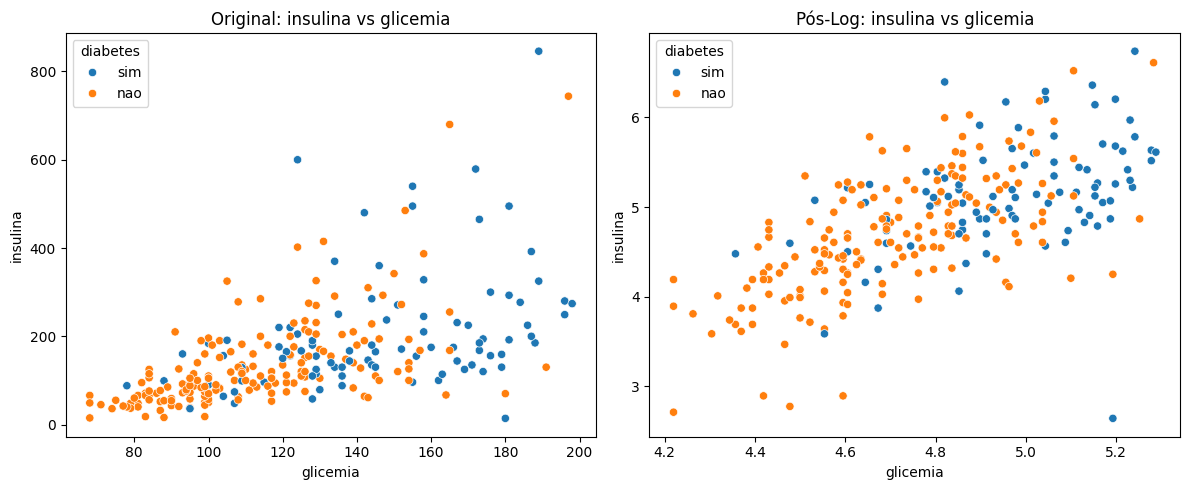

In [64]:
plot_comparison_log_transform(df, dados_tf, 'insulina', x_axis_variable='glicemia')

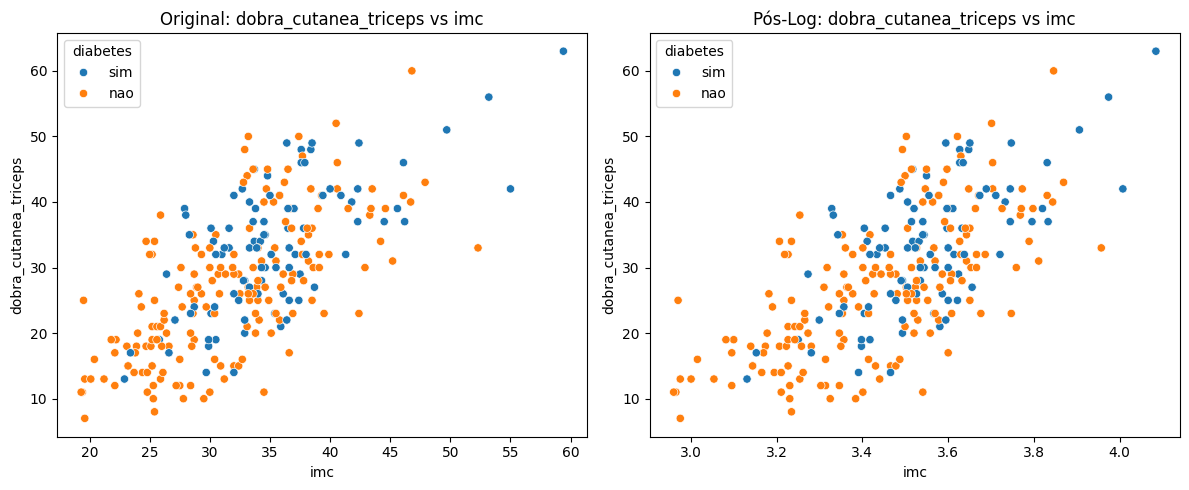

In [65]:
plot_comparison_log_transform(df, dados_tf, 'dobra_cutanea_triceps', x_axis_variable='imc')

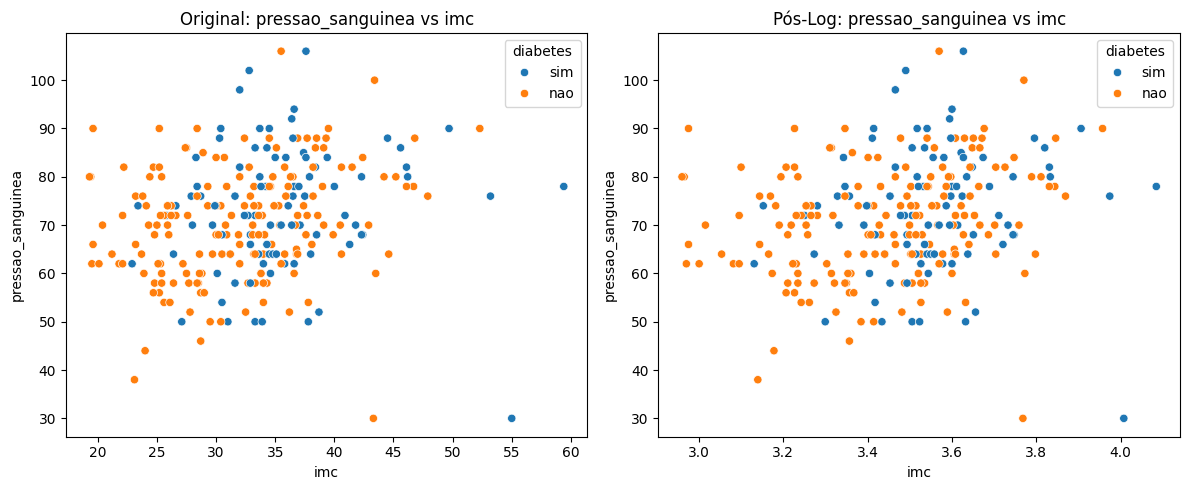

In [66]:
plot_comparison_log_transform(df, dados_tf, 'pressao_sanguinea', x_axis_variable='imc')

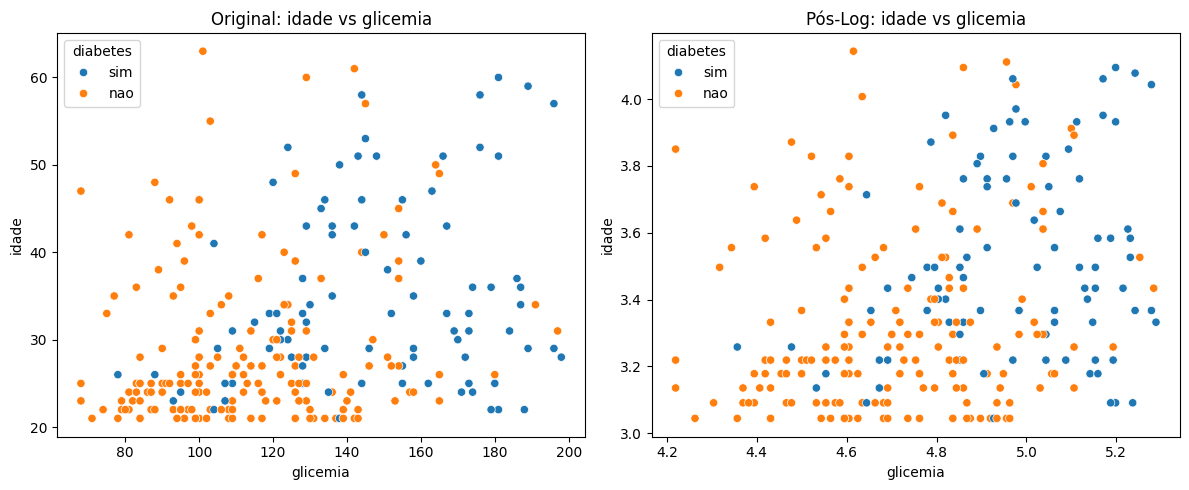

In [67]:
plot_comparison_log_transform(df, dados_tf, 'idade', x_axis_variable='glicemia')

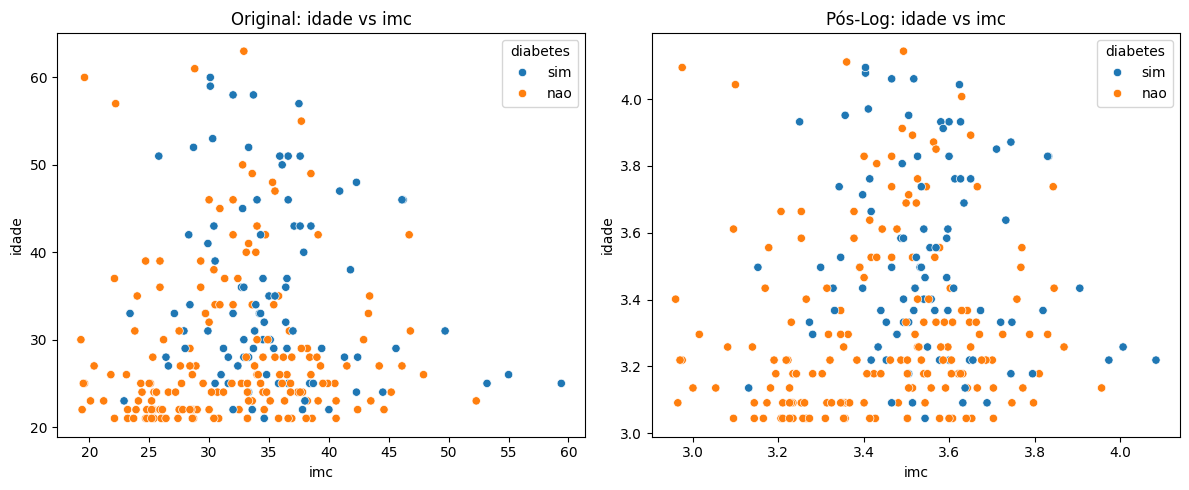

In [68]:
plot_comparison_log_transform(df, dados_tf, 'idade', x_axis_variable='imc')

O SVM funciona calculando distâncias. Imagine que cada variável é uma corda puxando a decisão para um lado.

Sem Log: A Glicemia tem uma variação grande (ex: de 80 a 300). Essa "distância" de 220 unidades dá muita força para essa variável no cálculo do hiperplano.

Com Log: Essa variação vira algo minúsculo (ex: 4.3 a 5.7). A "força" dessa variável agora é de apenas 1.4 unidades.

## Aprendizado semi-supervisionado

### Fazendo previsões

In [69]:
df[df['diabetes'].isna()]

,glicemia,pressao_sanguinea,dobra_cutanea_triceps,insulina,imc,idade,diabetes
0,89,66,23,94,28.1,21,NaN
1,137,40,35,168,43.1,33,NaN
3,197,70,45,543,30.5,53,NaN
6,118,84,47,230,45.8,31,NaN
11,125,70,26,115,31.1,41,NaN
...,...,...,...,...,...,...,...
373,149,68,29,127,29.3,42,NaN
382,102,44,20,94,30.8,26,NaN
384,153,88,37,140,40.6,39,NaN
386,81,74,41,57,46.3,32,NaN


In [70]:
dados_sem_rotulos = df[df['diabetes'].isna()].drop(columns = 'diabetes')
dados_sem_rotulos.head()

,glicemia,pressao_sanguinea,dobra_cutanea_triceps,insulina,imc,idade
0,89,66,23,94,28.1,21
1,137,40,35,168,43.1,33
3,197,70,45,543,30.5,53
6,118,84,47,230,45.8,31
11,125,70,26,115,31.1,41


In [71]:
dados_sem_rotulos_normalizados = pd.DataFrame(scaler_r.transform(dados_sem_rotulos), columns=dados_sem_rotulos.columns)
dados_sem_rotulos_normalizados

,glicemia,pressao_sanguinea,dobra_cutanea_triceps,insulina,imc,idade
0,-0.717391,-0.375,-0.3750,-0.309091,-0.607143,-0.545455
1,0.326087,-2.000,0.3750,0.363636,1.178571,0.545455
2,1.630435,-0.125,1.0000,3.772727,-0.321429,2.363636
3,-0.086957,0.750,1.1250,0.927273,1.500000,0.363636
4,0.065217,-0.125,-0.1875,-0.118182,-0.250000,1.272727
...,...,...,...,...,...,...
122,0.586957,-0.250,0.0000,-0.009091,-0.464286,1.363636
123,-0.434783,-1.750,-0.5625,-0.309091,-0.285714,-0.090909
124,0.673913,1.000,0.5000,0.109091,0.880952,1.090909
125,-0.891304,0.125,0.7500,-0.645455,1.559524,0.454545


In [72]:
y_previsto = svm.predict(dados_sem_rotulos_normalizados)

### Pseudo Labeling

In [73]:
novo_x_treino = pd.concat([x_treino, dados_sem_rotulos_normalizados], ignore_index=True)
novo_x_treino

,glicemia,pressao_sanguinea,dobra_cutanea_triceps,insulina,imc,idade
0,-0.282609,0.250,0.6250,-0.127273,-0.630952,0.363636
1,0.282609,-0.250,0.8125,1.109091,1.083333,-0.272727
2,-0.956522,-1.375,0.1875,-0.363636,-0.261905,-0.090909
3,0.434783,1.125,-0.3125,3.200000,-0.333333,1.454545
4,-0.413043,0.000,0.1875,0.563636,0.535714,2.545455
...,...,...,...,...,...,...
320,0.586957,-0.250,0.0000,-0.009091,-0.464286,1.363636
321,-0.434783,-1.750,-0.5625,-0.309091,-0.285714,-0.090909
322,0.673913,1.000,0.5000,0.109091,0.880952,1.090909
323,-0.891304,0.125,0.7500,-0.645455,1.559524,0.454545


In [74]:
novo_y_treino = pd.concat([pd.Series(y_treino), pd.Series(y_previsto)], ignore_index=True)
novo_y_treino

,0
0,1
1,1
2,1
3,1
4,0
...,...
320,1
321,0
322,1
323,0


In [75]:
pseudo_labeling = SVC(kernel = 'linear', random_state=10)
pseudo_labeling.fit(novo_x_treino, novo_y_treino)

SVC(kernel='linear', random_state=10)

In [76]:
novo_y_previsto = pseudo_labeling.predict(x_teste)
resultados_pseudo_labeling = classification_report(y_teste, novo_y_previsto)

In [77]:
print('SVM Supervisionado')
print(resultados_svm)
print('-'*55)
print('SVM Pseudo Labeling')
print(resultados_pseudo_labeling)

SVM Supervisionado
              precision    recall  f1-score   support

           0       0.86      0.95      0.90        44
           1       0.89      0.70      0.78        23

    accuracy                           0.87        67
   macro avg       0.87      0.83      0.84        67
weighted avg       0.87      0.87      0.86        67

-------------------------------------------------------
SVM Pseudo Labeling
              precision    recall  f1-score   support

           0       0.85      0.93      0.89        44
           1       0.84      0.70      0.76        23

    accuracy                           0.85        67
   macro avg       0.85      0.81      0.83        67
weighted avg       0.85      0.85      0.85        67



## Self Training

### Tabela de probabilidade

In [78]:
x_treino, x_teste, y_treino, y_teste = train_test_split(x_normalizado, y, stratify = y, random_state = 10)

In [79]:
svm = SVC(kernel = 'linear', probability = True, random_state = 10)
svm.fit(x_treino, y_treino)

SVC(kernel='linear', probability=True, random_state=10)

In [80]:
probabilidades = svm.predict_proba(dados_sem_rotulos_normalizados)
y_previsto = svm.predict(dados_sem_rotulos_normalizados)

In [81]:
tabela_resultados = pd.DataFrame(probabilidades, columns = ['Prob C0', 'Prob C1'])
tabela_resultados['Previsão'] = y_previsto
tabela_resultados['Probabilidade máxima'] = tabela_resultados[['Prob C0', 'Prob C1']].max(axis = 1)
tabela_resultados

,Prob C0,Prob C1,Previsão,Probabilidade máxima
0,0.875821,0.124179,0,0.875821
1,0.430063,0.569937,1,0.569937
2,0.209233,0.790767,1,0.790767
3,0.584221,0.415779,0,0.584221
4,0.638188,0.361812,0,0.638188
...,...,...,...,...
122,0.480279,0.519721,1,0.519721
123,0.793330,0.206670,0,0.793330
124,0.409032,0.590968,1,0.590968
125,0.735386,0.264614,0,0.735386


### Selecionando rótulos com maior confiança

Text(0.5, 0, 'Probabilidade Máxima')

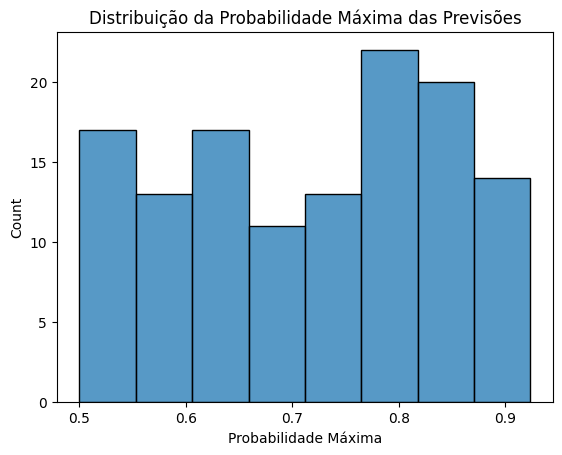

In [82]:
sns.histplot(x='Probabilidade máxima', data=tabela_resultados)
plt.title('Distribuição da Probabilidade Máxima das Previsões')
plt.xlabel('Probabilidade Máxima')

In [83]:
tabela_resultados['Probabilidade máxima'] > 0.75

,Probabilidade máxima
0,True
1,False
2,True
3,False
4,False
...,...
122,False
123,True
124,False
125,False


In [84]:
filtro_confianca = tabela_resultados['Probabilidade máxima'] > 0.75
novo_x_treino = pd.concat([x_treino, dados_sem_rotulos_normalizados[filtro_confianca]])
novo_y_treino = pd.concat([pd.Series(y_treino), tabela_resultados.loc[filtro_confianca, 'Previsão']])

### Modelo aprimorado

In [85]:
svm = SVC(kernel= 'linear', probability=True, random_state=10)
svm.fit(novo_x_treino, novo_y_treino)

SVC(kernel='linear', probability=True, random_state=10)

In [86]:
novo_y_previsto = svm.predict(x_teste)
resultados_self_training1 = classification_report(y_teste, novo_y_previsto)

In [87]:
print('SVM Supervisionado')
print(resultados_svm)
print('-'*55)
print('SVM Self Training 1º estágio')
print(resultados_self_training1)

SVM Supervisionado
              precision    recall  f1-score   support

           0       0.86      0.95      0.90        44
           1       0.89      0.70      0.78        23

    accuracy                           0.87        67
   macro avg       0.87      0.83      0.84        67
weighted avg       0.87      0.87      0.86        67

-------------------------------------------------------
SVM Self Training 1º estágio
              precision    recall  f1-score   support

           0       0.86      0.95      0.90        44
           1       0.89      0.70      0.78        23

    accuracy                           0.87        67
   macro avg       0.87      0.83      0.84        67
weighted avg       0.87      0.87      0.86        67



### Modelo Self Training

In [88]:
from sklearn.semi_supervised import SelfTrainingClassifier

In [89]:
pd.Series([-1]*dados_sem_rotulos_normalizados.shape[0])

,0
0,-1
1,-1
2,-1
3,-1
4,-1
...,...
122,-1
123,-1
124,-1
125,-1


In [90]:
x_treino_self_training = pd.concat([x_treino, dados_sem_rotulos_normalizados], ignore_index = True)
y_treino_self_training = pd.concat([pd.Series(y_treino), pd.Series([-1]*dados_sem_rotulos_normalizados.shape[0])], ignore_index = True)

In [91]:
svm = SVC(kernel = 'linear', probability= True, random_state = 10)

In [92]:
svm = SVC(kernel = 'linear', probability= True, random_state = 10)
self_training = SelfTrainingClassifier(svm, threshold = 0.80, max_iter = 15, verbose = True)

In [93]:
self_training.fit(x_treino_self_training, y_treino_self_training)

End of iteration 1, added 43 new labels.
End of iteration 2, added 20 new labels.
End of iteration 3, added 3 new labels.


SelfTrainingClassifier(estimator=SVC(kernel='linear', probability=True,
                                     random_state=10),
                       max_iter=15, threshold=0.8, verbose=True)

In [94]:
y_previsto = self_training.predict(x_teste)
resultados_self_training = classification_report(y_teste, y_previsto)

In [95]:
print('SVM Supervisionado')
print(resultados_svm)
print('-'*55)
print('SVM Self Training 1º estágio')
print(resultados_self_training1)
print('-'*55)
print('SVM Self Training')
print(resultados_self_training)

SVM Supervisionado
              precision    recall  f1-score   support

           0       0.86      0.95      0.90        44
           1       0.89      0.70      0.78        23

    accuracy                           0.87        67
   macro avg       0.87      0.83      0.84        67
weighted avg       0.87      0.87      0.86        67

-------------------------------------------------------
SVM Self Training 1º estágio
              precision    recall  f1-score   support

           0       0.86      0.95      0.90        44
           1       0.89      0.70      0.78        23

    accuracy                           0.87        67
   macro avg       0.87      0.83      0.84        67
weighted avg       0.87      0.87      0.86        67

-------------------------------------------------------
SVM Self Training
              precision    recall  f1-score   support

           0       0.86      0.95      0.90        44
           1       0.89      0.70      0.78        23

    

## Concluindo Projeto

### Label Propagation

In [96]:
from sklearn.semi_supervised import LabelPropagation

In [97]:
label_propagation = LabelPropagation()

label_propagation.fit(x_treino_self_training, y_treino_self_training)

/usr/local/lib/python3.12/dist-packages/sklearn/semi_supervised/_label_propagation.py:324: ConvergenceWarning: max_iter=1000 was reached without convergence.
  warnings.warn(


LabelPropagation()

In [98]:
y_previsto = label_propagation.predict(x_teste)
resultados_label_propagation = classification_report(y_teste, y_previsto)

In [99]:
print('SVM Self Training')
print(resultados_self_training)
print('-'*50)
print('Label Propagation')
print(resultados_label_propagation)

SVM Self Training
              precision    recall  f1-score   support

           0       0.86      0.95      0.90        44
           1       0.89      0.70      0.78        23

    accuracy                           0.87        67
   macro avg       0.87      0.83      0.84        67
weighted avg       0.87      0.87      0.86        67

--------------------------------------------------
Label Propagation
              precision    recall  f1-score   support

           0       0.80      0.82      0.81        44
           1       0.64      0.61      0.62        23

    accuracy                           0.75        67
   macro avg       0.72      0.71      0.72        67
weighted avg       0.74      0.75      0.74        67

